In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


## Image Dataset (training on full frames)

Inspect dataset:

In [3]:
from dataset import ImageDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = ImageDataset(VALIDATION_PATH, transform)
sample = next(iter(dataset))
print(sample.shape)

torch.Size([3, 64, 64])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

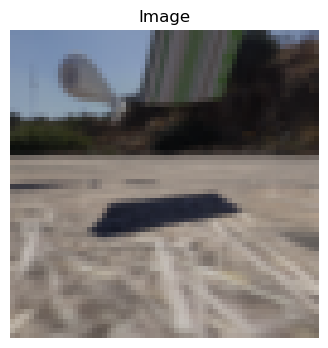

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Image")
plt.axis("off")

### Prepare dataset for training an autoencoder

In [5]:
train_dataset = ImageDataset(TRAIN_PATH, transform)
val_dataset = ImageDataset(VALIDATION_PATH, transform)

In [19]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

### Define and train an autoencoder

In [ ]:
# from models.autoencoder import ImageAutoencoder
from models.encoder import ViTPatchEncoder
from models.decoder import ViTPatchDecoder

PATCH_SIZE = 16
H, W = 64, 64
encoder = ViTPatchEncoder(patch_size=PATCH_SIZE,
                          embed_dim=256,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=128,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)

decoder = ViTPatchDecoder(patch_size=PATCH_SIZE,
                          H = 64,
                          W = 64,
                          embed_dim=256,
                          max_len=(64 // PATCH_SIZE) * (64 // PATCH_SIZE),
                          attn_dim=128,
                          num_heads=4,
                          mlp_size=512,
                          num_tf_layers=4)


# autoencoder_img = ImageAutoencoder(encoder, decoder, PATCH_SIZE)

#### Image autoencoder

In [13]:
import torch.nn as nn

class ImageAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 64x64 → 4x4
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=4, stride=2, padding=1),   # 64x64 → 32x32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 32x32 → 16x16
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 16x16 → 8x8
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),# 8x8 → 4x4
            nn.ReLU()
        )

        # Decoder: 4x4 → 64x64
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), # 4x4 → 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 8x8 → 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 16x16 → 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 32x32 → 64x64
            nn.Sigmoid()  # [0,1] output
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [16]:
from train import Trainer
from evaluate import evaluate_autoencoder

autoencoder_img = ImageAutoencoder()

In [14]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(autoencoder_img.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler)
trainer.train(train_loader, val_loader, 5)



  0%|                                                                                                                                        | 0/5 [00:00<?, ?it/s]

Ep 0 Iter 0: Loss=1.11686):   0%|                                                                                                            | 0/5 [00:01<?, ?it/s]

Ep 0 Iter 1: Loss=0.59751):   0%|                                                                                                            | 0/5 [00:08<?, ?it/s]

Ep 0 Iter 2: Loss=0.40802):   0%|                                                                                                            | 0/5 [00:08<?, ?it/s]

Ep 0 Iter 3: Loss=0.32414):   0%|                                                                                                            | 0/5 [00:08<?, ?it/s]

Ep 0 Iter 4: Loss=0.24923):   0%|                                                                                                            | 0/5 [00:08<?, ?it/s]

Ep 0 Ite

{'iter': 0, 'batch_size': 64, 'epoch': 0, 'loss': 1.1168617010116577, 'Loss': 0.5850208360464015, 'SSIM': 0.009016646892657932, 'PSNR': 8.95052474630866}




Ep 0 Iter 9: Loss=0.09159):   0%|                                                                                                            | 0/5 [00:09<?, ?it/s]

Ep 0 Iter 10: Loss=0.09357):   0%|                                                                                                           | 0/5 [00:09<?, ?it/s]

Ep 0 Iter 11: Loss=0.09416):   0%|                                                                                                           | 0/5 [00:09<?, ?it/s]

Ep 0 Iter 12: Loss=0.0823):   0%|                                                                                                            | 0/5 [00:09<?, ?it/s]

Ep 0 Iter 13: Loss=0.08717):   0%|                                                                                                           | 0/5 [00:10<?, ?it/s]

Ep 0 Iter 14: Loss=0.0826):   0%|                                                                                                            | 0/5 [00:10<?, ?it/s]

Ep 0 Ite

{'iter': 1000, 'batch_size': 64, 'epoch': 0, 'loss': 0.013935173861682415, 'Loss': 0.01673238096322785, 'SSIM': 0.561033580497957, 'PSNR': 18.60831863155554}




Ep 0 Iter 1002: Loss=0.01765):   0%|                                                                                                         | 0/5 [01:34<?, ?it/s]

Ep 0 Iter 1003: Loss=0.01619):   0%|                                                                                                         | 0/5 [01:34<?, ?it/s]

Ep 0 Iter 1004: Loss=0.01592):   0%|                                                                                                         | 0/5 [01:34<?, ?it/s]

Ep 0 Iter 1005: Loss=0.01741):   0%|                                                                                                         | 0/5 [01:34<?, ?it/s]

Ep 0 Iter 1006: Loss=0.01548):   0%|                                                                                                         | 0/5 [01:34<?, ?it/s]

Ep 0 Iter 1007: Loss=0.01674):   0%|                                                                                                         | 0/5 [01:34<?, ?it/s]

Ep 0 Ite

...



Ep 4 Iter 17001: Loss=0.00333):   0%|                                                                                                        | 0/5 [13:38<?, ?it/s]

Ep 4 Iter 17002: Loss=0.0032):   0%|                                                                                                         | 0/5 [13:38<?, ?it/s]

Ep 4 Iter 17003: Loss=0.0029):   0%|                                                                                                         | 0/5 [13:38<?, ?it/s]

Ep 4 Iter 17004: Loss=0.00288):   0%|                                                                                                        | 0/5 [13:38<?, ?it/s]

Ep 4 Iter 17005: Loss=0.00307):   0%|                                                                                                        | 0/5 [13:38<?, ?it/s]

Ep 4 Iter 17006: Loss=0.00251):   0%|                                                                                                        | 0/5 [13:38<?, ?it/s]

Ep 4 Ite

{'iter': 18000, 'batch_size': 64, 'epoch': 4, 'loss': 0.0033528520725667477, 'Loss': 0.006692734408251783, 'SSIM': 0.8511710348461697, 'PSNR': 23.179366356868083}




Ep 4 Iter 18001: Loss=0.0025):   0%|                                                                                                         | 0/5 [14:20<?, ?it/s]

Ep 4 Iter 18002: Loss=0.00258):   0%|                                                                                                        | 0/5 [14:20<?, ?it/s]

Ep 4 Iter 18003: Loss=0.00284):   0%|                                                                                                        | 0/5 [14:20<?, ?it/s]

Ep 4 Iter 18004: Loss=0.00298):   0%|                                                                                                        | 0/5 [14:20<?, ?it/s]

Ep 4 Iter 18005: Loss=0.00319):   0%|                                                                                                        | 0/5 [14:20<?, ?it/s]

Ep 4 Iter 18006: Loss=0.00261):   0%|                                                                                                        | 0/5 [14:20<?, ?it/s]

Ep 4 Ite

Saved epoch_18255_iter_18256's state to experiments/02-41_19-08-2025_ConvAE/checkpoints/epoch_18255_iter_18256.pth
Training completed


KeyboardInterrupt: 

##### Inspect reconstruction of a random sample

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.056644425..0.7834426].


torch.Size([1, 3, 64, 64])


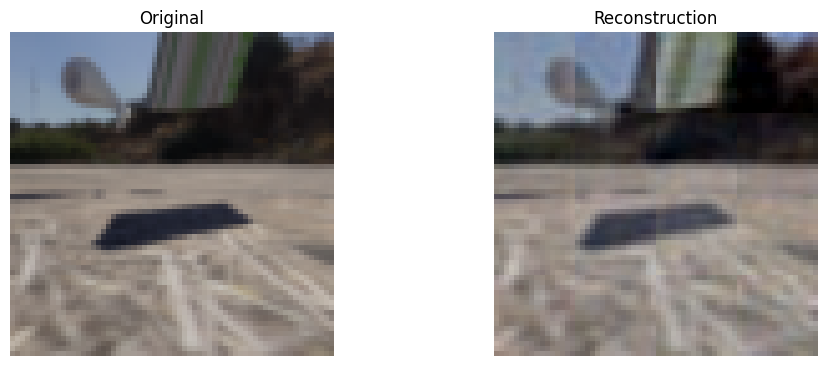

In [23]:
sample = next(iter(val_dataset))
sample = sample.unsqueeze(0) # sample is of shape [B, C, H, W]
reconstr = autoencoder_img(sample.to(device))

print(reconstr.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.squeeze(0).permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstr.squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

## Mask Autoencoder

Prepare dataset

In [3]:
from dataset import MaskDataset
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = MaskDataset(TRAIN_PATH, transform)
val_dataset = MaskDataset(VALIDATION_PATH, transform)

In [4]:
B_SIZE = 16

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
)
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

In [5]:
batch = next(iter(val_loader))
batch[1].shape # (batch size, width, height)

torch.Size([16, 64, 64])

In [6]:
import torch.nn.functional as F
from train import Trainer
from models.masked_object_transformer import MaskedObjectTransformer

def save_models(model, optimizer, scheduler, stats, model_name, save_path):
    torch.save({
        'encoder_state_dict': model.encoder.state_dict(),
        'decoder_state_dict': model.decoder.state_dict(),
        'stats': stats
    }, save_path)

def reconstruction_loss(ins, outs, mode='l1'):
    imgs, masks = ins
    
    if mode == 'l1':
        return F.l1_loss(outs, imgs)
    elif mode == 'mse':
        return F.mse_loss(outs, imgs)
    else:
        raise ValueError

autoencoder_obj = MaskedObjectTransformer(obj_num=10, embed_dim=256,
                                          img_size=64, patch_size=8,
                                          enc_depth=3, dec_depth=3,
                                          nhead=8, mlp_ratio=4.0)

optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=3e-4, weight_decay=.05)
trainer = Trainer(model=autoencoder_obj, evaluate=None,
                  optimizer=optimizer, experiment_name="Mask_AE",
                  criterion=lambda outs, ins : reconstruction_loss(ins, outs))
trainer.train(train_loader, val_loader, 3)


Ep 0 Iter 29210: Loss=0.04423):   0%|          | 0/3 [14:47<?, ?it/s]

Saved epoch_001_iter_29211's state to experiments/12-09-2025_20-26_Mask_AE/checkpoints/epoch_001_iter_29211.pth


Ep 1 Iter 58421: Loss=0.04139):   0%|          | 0/3 [29:28<?, ?it/s]

Saved epoch_001_iter_58421's state to experiments/12-09-2025_20-26_Mask_AE/checkpoints/epoch_001_iter_58421.pth


Ep 2 Iter 87632: Loss=0.0392):   0%|          | 0/3 [44:10<?, ?it/s] 

Saved epoch_002_iter_87631's state to experiments/12-09-2025_20-26_Mask_AE/checkpoints/epoch_002_iter_87631.pth
Training completed
Saved epoch_003_iter_87633's state to experiments/12-09-2025_20-26_Mask_AE/checkpoints/epoch_003_iter_87633.pth


Display results:

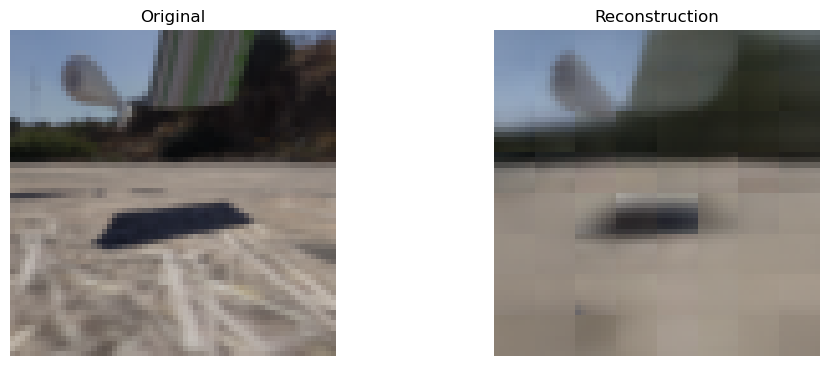

In [7]:
import matplotlib.pyplot as plt
batch = next(iter(val_loader))
sample = batch[0].to(device)
sample_masks = batch[1].to(device)

sample_out = autoencoder_obj((sample, sample_masks))
img_out = sample_out

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample[0].cpu().detach().permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_out[0].cpu().detach().squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

#### Old version of object autoencoder

Test object slicing & composing

Dataset item  torch.Size([3, 64, 64]) torch.Size([64, 64])
Latent repr:  torch.Size([1, 10, 3, 64, 64])
Reconstr repr:  torch.Size([1, 3, 64, 64])
Error tensor(0.)


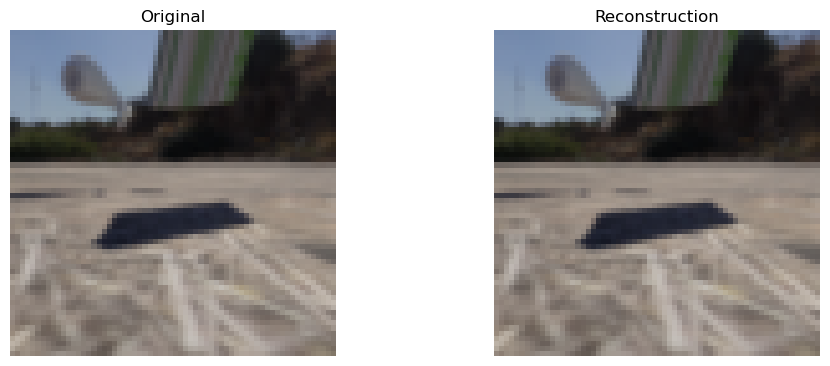

In [6]:
from models.object_composer import ObjectSlicer, ObjectComposer
import matplotlib.pyplot as plt

item = next(iter(val_dataset))
img, mask = item
print('Dataset item ', img.size(), mask.size())

obj_encoder = ObjectSlicer()
obj_decoder = ObjectComposer()

latent_img = obj_encoder(img.unsqueeze(0), mask.unsqueeze(0))
print("Latent repr: ", latent_img.size())
rec_img = obj_decoder(latent_img, mask.unsqueeze(0))
print("Reconstr repr: ", rec_img.size())
print("Error", torch.nn.functional.mse_loss(img.unsqueeze(0), rec_img))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rec_img.squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

Training

In [ ]:
import torch.nn.functional as F
from models.masked_object_transformer_old import MaskedObjectTransformer
from train import Trainer

def reconstruction_loss(pred, target, mode='l1'):
    if mode == 'l1':
        return F.l1_loss(pred, target)
    elif mode == 'mse':
        return F.mse_loss(pred, target)
    else:
        raise ValueError

autoencoder_obj = MaskedObjectTransformer(obj_num=10, embed_dim=256,
                                          img_size=64, patch_size=8,
                                          enc_depth=3, dec_depth=3,
                                          nhead=8, mlp_ratio=4.0)

optimizer = torch.optim.AdamW(autoencoder_obj.parameters(), lr=3e-4, weight_decay=.05)
trainer = Trainer(model=autoencoder_obj, evaluate=None,
                  optimizer=optimizer, experiment_name="Mask_AE",
                  criterion=lambda outs, ins : reconstruction_loss(outs[1], ins[0]))
trainer.train(train_loader, val_loader, 5)


Ep 0 Iter 7302: Loss=0.07031):   0%|          | 0/5 [12:09<?, ?it/s]

Saved epoch_001_iter_07303's state to experiments/04-09-2025_06-07_Mask_AE/checkpoints/epoch_001_iter_07303.pth


Ep 1 Iter 14605: Loss=0.05752):   0%|          | 0/5 [24:19<?, ?it/s]

Saved epoch_001_iter_14605's state to experiments/04-09-2025_06-07_Mask_AE/checkpoints/epoch_001_iter_14605.pth


Ep 2 Iter 21908: Loss=0.05453):   0%|          | 0/5 [36:29<?, ?it/s]

...

Saved epoch_003_iter_29209's state to experiments/04-09-2025_06-07_Mask_AE/checkpoints/epoch_003_iter_29209.pth


Ep 4 Iter 36512: Loss=0.05945):   0%|          | 0/5 [1:00:48<?, ?it/s]

Saved epoch_004_iter_36511's state to experiments/04-09-2025_06-07_Mask_AE/checkpoints/epoch_004_iter_36511.pth


Ep 4 Iter 36514: Loss=0.04495):   0%|          | 0/5 [1:00:48<?, ?it/s]

Training completed


Display result

In [9]:
batch = next(iter(val_loader))
sample = batch[0].to(device)
sample_masks = batch[1].to(device)

sample_out = autoencoder_obj((sample, sample_masks))

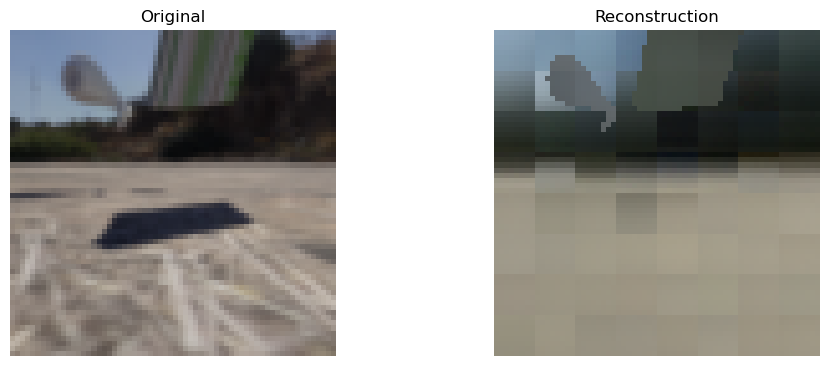

In [ ]:
img_out = sample_out[1]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample[0].cpu().detach().permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_out[0].cpu().detach().squeeze(0).permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()